Best Youden's J Statistic: 0.6337
Optimal Threshold for J: 0.4491

Odds Ratios:
Sex_male: 0.0779
Pclass: 0.3486


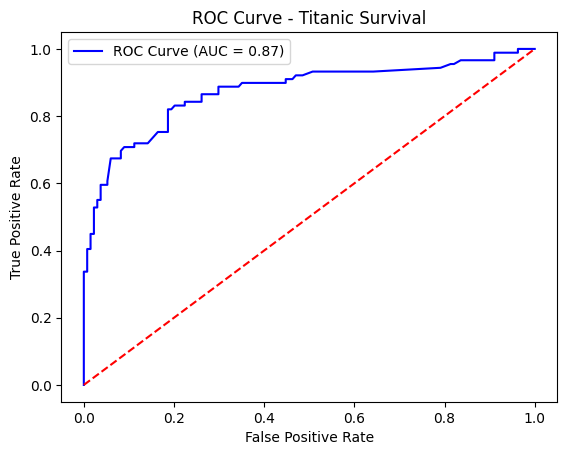

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

data = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data_encoded = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

features = ['Pclass', 'Sex_male', 'Age', 'SibSp']
X = data_encoded[features]
y = data_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

youden_j = tpr - fpr
best_threshold_idx = np.argmax(youden_j)
print(f"Best Youden's J Statistic: {youden_j[best_threshold_idx]:.4f}")
print(f"Optimal Threshold for J: {thresholds[best_threshold_idx]:.4f}")

odds_ratios = np.exp(model.coef_[0])
odds_dict = dict(zip(X.columns, odds_ratios))

print("\nOdds Ratios:")
print(f"Sex_male: {odds_dict.get('Sex_male', 0):.4f}")
print(f"Pclass: {odds_dict.get('Pclass', 0):.4f}")

plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Titanic Survival')
plt.legend()
plt.show()